# Generalizability

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

In [113]:
experiment = "generalizability"

dataset = "aitv2"

In [114]:
experiments = {}

In [115]:
metrics_dir = Path(f"../../experiments/{dataset}/{experiment}/deepproblog/metrics")
file_paths = list(metrics_dir.iterdir())

f1_scores = {}
false_positives = {}
detection_rates = {}

for file_path in file_paths:
    experiment_name = str(file_path.stem)

    # print(f"Processing {experiment_name}...")
    data = np.load(file_path, allow_pickle=True)
    metrics = data["metrics"].item()

    exp_name = f"dpl_{experiment_name}"
    experiments[exp_name] = {
        "f1_score": metrics["macro_f1"],
        "false_alarm_rate": metrics["false_alarm_rate"],
        "detection_rate": metrics["detection_rate"]
    }


In [116]:
metrics_dir = Path(f"../../experiments/{dataset}/{experiment}/baselines/metrics")
file_paths = list(metrics_dir.iterdir())

for file_path in file_paths:
    experiment_name = str(file_path.stem)
    
    # print(f"Processing {experiment_name}...")
    with open(file_path) as f:
        metrics = json.load(f)
    
    exp_name = f"baseline_{experiment_name}"

    experiments[exp_name] = {
        "f1_score": metrics["Macro F1"],
        "false_alarm_rate": metrics["False Alarm Rate"],
        "detection_rate": metrics["Detection Rate"]
    }


In [117]:
experiments

{'dpl_fox_pretrained': {'f1_score': 0.8798152850175956,
  'false_alarm_rate': 4.374835943652113e-05,
  'detection_rate': 0.9990169919955062},
 'dpl_santos_fox_logic_baseline': {'f1_score': 0.6446858921650247,
  'false_alarm_rate': 0.11790557854080472,
  'detection_rate': 0.9998455273135796},
 'dpl_santos_fox_pretrained': {'f1_score': 0.5039456473375399,
  'false_alarm_rate': 0.000369986125520293,
  'detection_rate': 0.4760707765763236},
 'dpl_fox_scratch': {'f1_score': 0.7024739753291103,
  'false_alarm_rate': 0.0008874667199980001,
  'detection_rate': 0.9927327622524926},
 'dpl_santos_fox_scratch': {'f1_score': 0.7856257534611599,
  'false_alarm_rate': 0.007227228978913291,
  'detection_rate': 0.9959134952956046},
 'baseline_fox': {'f1_score': 0.8585183136300151,
  'false_alarm_rate': 0.00024374085971776057,
  'detection_rate': 0.9988413328183702},
 'baseline_santos_fox': {'f1_score': 0.5352381139387197,
  'false_alarm_rate': 0.1029936377385848,
  'detection_rate': 0.5771845138410009}

In [118]:
plots_dir = Path(f"../../reports/{dataset}/{experiment}")

In [119]:
def metrics_bar_chart(experiments, plots_dir=None, plots_title="Model Comparison"):
    plt.style.use('seaborn-v0_8-whitegrid')
    
    metrics = ['f1_score', 'detection_rate', 'false_alarm_rate']
    metric_labels = ['F1 Score', 'Detection Rate', 'False Alarm Rate']
    
    exp_names = list(experiments.keys())
    n_experiments = len(exp_names)
    n_metrics = len(metrics)
    
    # Create figure with two subplots (FAR has very different scale)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2, 1]})
    
    # Colors for each metric
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    
    # ===== Left plot: F1 Score and Detection Rate =====
    x = np.arange(n_experiments)
    width = 0.35
    
    for i, (metric, label, color) in enumerate(zip(metrics[:2], metric_labels[:2], colors[:2])):
        values = [experiments[exp][metric] for exp in exp_names]
        offset = (i - 0.5) * width
        bars = ax1.bar(x + offset, values, width, label=label, color=color, edgecolor='white', linewidth=0.7)
        
        # Add value labels on bars
        for bar, val in zip(bars, values):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                     f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='medium')
    
    ax1.set_ylabel('Score', fontsize=12, fontweight='medium')
    ax1.set_title('F1 Score & Detection Rate', fontsize=13, fontweight='bold', pad=15)
    ax1.set_xticks(x)
    ax1.set_xticklabels([name.replace('_', '\n') for name in exp_names], fontsize=9)
    ax1.set_ylim(0, 1.15)
    ax1.legend(loc='upper right', fontsize=10)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # ===== Right plot: False Alarm Rate (different scale) =====
    far_values = [experiments[exp]['false_alarm_rate'] for exp in exp_names]
    bars = ax2.bar(x, far_values, width=0.6, color=colors[2], edgecolor='white', linewidth=0.7)
    
    # Add value labels
    for bar, val in zip(bars, far_values):
        label_text = f'{val:.4f}' if val < 0.01 else f'{val:.3f}'
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
                 label_text, ha='center', va='bottom', fontsize=8, fontweight='medium', rotation=45)
    
    ax2.set_ylabel('Rate', fontsize=12, fontweight='medium')
    ax2.set_title('False Alarm Rate (lower is better)', fontsize=13, fontweight='bold', pad=15)
    ax2.set_xticks(x)
    ax2.set_xticklabels([name.replace('_', '\n') for name in exp_names], fontsize=9)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    fig.suptitle(plots_title, fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if plots_dir:
        plots_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(plots_dir / "metrics_comparison.png", dpi=150, bbox_inches='tight')
    
    plt.show()


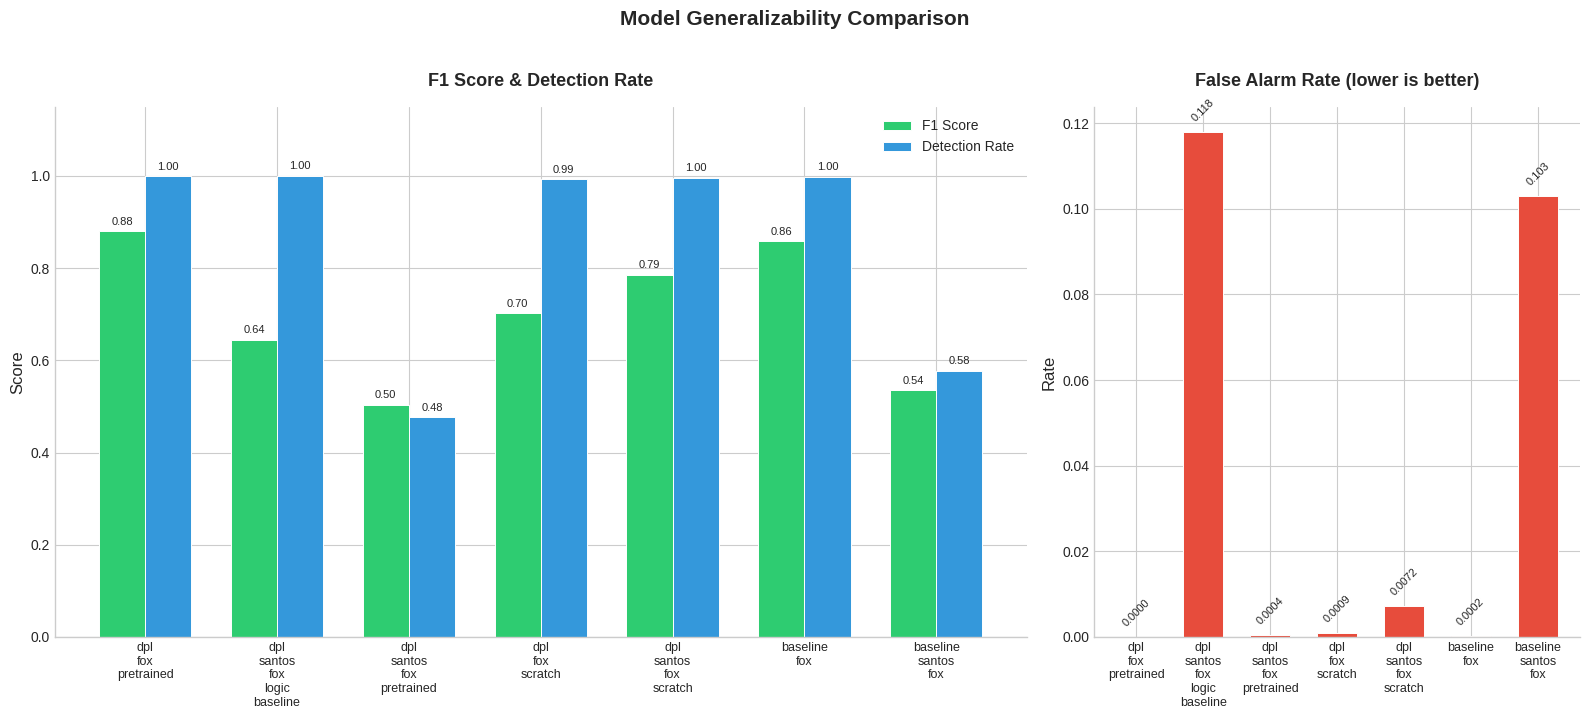

In [120]:
metrics_bar_chart(experiments, plots_dir=plots_dir, plots_title="Model Generalizability Comparison")

In [123]:
import matplotlib.pyplot as plt
import numpy as np

def metrics_heatmap(experiments, plots_dir=None, plots_title="Model Comparison"):

    plt.style.use('default')

    metrics = ['f1_score', 'detection_rate', 'false_alarm_rate']
    metric_labels = ['F1 Score', 'Detection Rate', 'False Alarm Rate']
    
    exp_names = list(experiments.keys())
    
    # Build matrix
    data = np.array([[experiments[exp][m] for m in metrics] for exp in exp_names])
    
    # Normalize columns to 0–1 for consistent color scaling
    data_norm = data.copy()
    data_norm[:, 2] = 1 - data_norm[:, 2]  # invert FAR
    for col in range(data_norm.shape[1]):
        col_min, col_max = data_norm[:, col].min(), data_norm[:, col].max()
        if col_max > col_min:
            data_norm[:, col] = (data_norm[:, col] - col_min) / (col_max - col_min)
    
    fig, ax = plt.subplots(figsize=(8, 10))
    im = ax.imshow(data_norm, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metric_labels, fontsize=11, fontweight='medium')
    ax.set_yticks(range(len(exp_names)))
    ax.set_yticklabels([name.replace('_', ' ') for name in exp_names], fontsize=10)
    
    # Annotate cells with actual values
    for i in range(len(exp_names)):
        for j in range(len(metrics)):
            val = data[i, j]
            text = f'{val:.3f}' if val < 0.01 or j == 2 else f'{val:.2f}'
            color = 'white' if data_norm[i, j] < 0.3 or data_norm[i, j] > 0.7 else 'black'
            ax.text(j, i, text, ha='center', va='center', fontsize=12, color=color, fontweight='medium')
    
    ax.set_title(plots_title, fontsize=14, fontweight='bold', pad=15)
    cbar = plt.colorbar(im, ax=ax, shrink=0.6)
    cbar.set_label('Relative Performance (green = better)', fontsize=10)
    
    plt.tight_layout()
    if plots_dir:
        plots_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(plots_dir / "metrics_heatmap.png", dpi=150, bbox_inches='tight')
    plt.show()


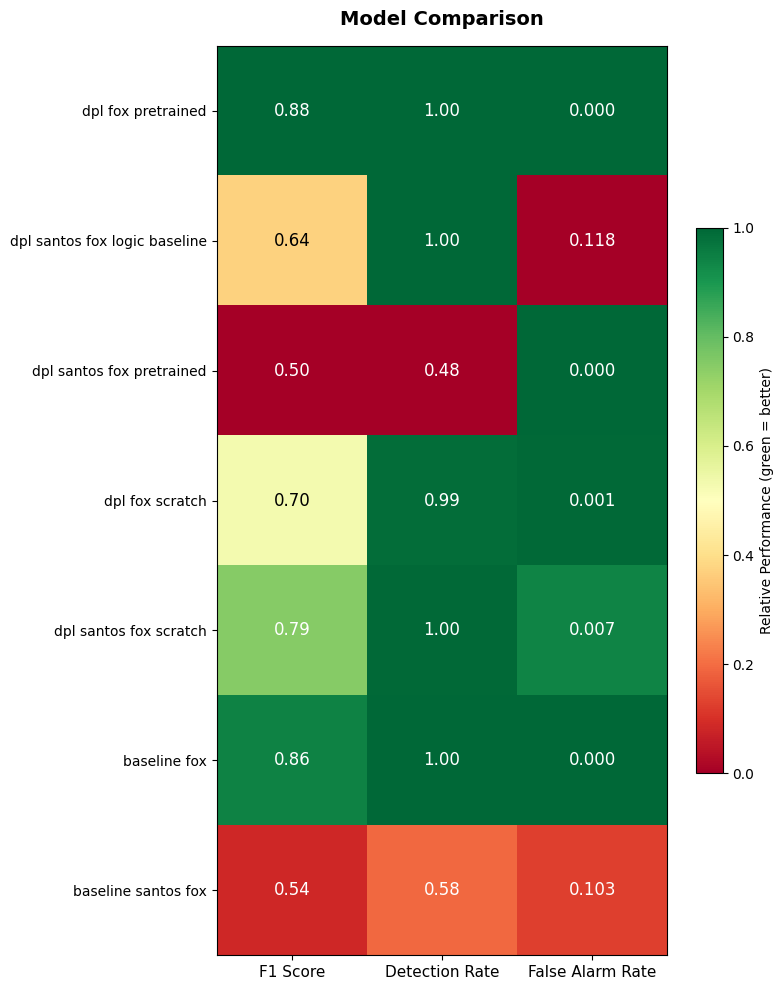

In [124]:
metrics_heatmap(experiments, plots_dir=plots_dir, plots_title="Model Comparison")

In [137]:
experiments_df = pd.DataFrame(experiments).T
experiments_df

,f1_score,false_alarm_rate,detection_rate
dpl_fox_pretrained,0.879815,0.000044,0.999017
dpl_santos_fox_logic_baseline,0.644686,0.117906,0.999846
dpl_santos_fox_pretrained,0.503946,0.000370,0.476071
dpl_fox_scratch,0.702474,0.000887,0.992733
dpl_santos_fox_scratch,0.785626,0.007227,0.995913
baseline_fox,0.858518,0.000244,0.998841
baseline_santos_fox,0.535238,0.102994,0.577185


In [139]:
experiments_sorted = experiments_df.sort_values(by='f1_score', ascending=False)
experiments_sorted

,f1_score,false_alarm_rate,detection_rate
dpl_fox_pretrained,0.879815,0.000044,0.999017
baseline_fox,0.858518,0.000244,0.998841
dpl_santos_fox_scratch,0.785626,0.007227,0.995913
dpl_fox_scratch,0.702474,0.000887,0.992733
dpl_santos_fox_logic_baseline,0.644686,0.117906,0.999846
baseline_santos_fox,0.535238,0.102994,0.577185
dpl_santos_fox_pretrained,0.503946,0.000370,0.476071


In [140]:
# save sorted results to CSV
experiments_sorted.to_csv(plots_dir / "generalizability_results.csv", index=True)